In [1]:
import numpy as np
from SADDlE import assembleAm, generalDDE
import scipy.sparse.linalg as lin
import matplotlib.pyplot as plt

In [2]:
D = np.array([[40.0, 1.0], [-7.0, 1.0]])
D_inv = np.linalg.inv(D)

A = np.array([[0,1], [-1, 0]])
B = np.array([[3, 0], [0,0]])
B2 = 2 * B

dde = generalDDE(2, [np.pi * 2], None, None, D_inv @ A, [D_inv @ B], None)
x = lin.eigs(assembleAm(dde.convertToTheoreticalDDE(), 100, False), k=50, which='LR')[0]


In [112]:
D_big = np.identity(202)
D_big[0:2, 0:2] = D
D_big

dde2 = generalDDE(2, [np.pi * 2], None, None, A, [B], None)
y = lin.eigs(assembleAm(dde2.convertToTheoreticalDDE(), 100, False), k=50, M=D_big, which='LR')[0]
z = lin.eigs(D_big @ assembleAm(dde.convertToTheoreticalDDE(), 100, False), k=50, M=D_big, which='LR')[0]


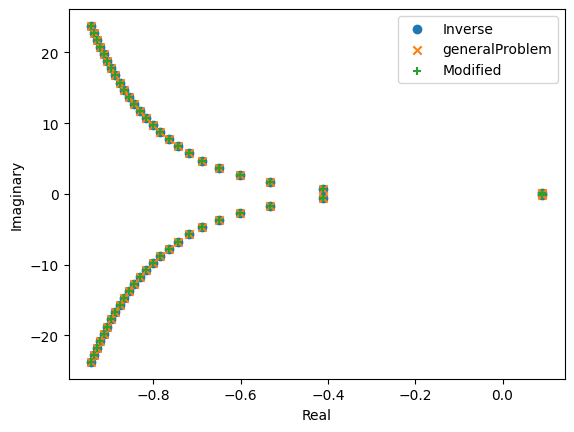

In [113]:
x1 = [val.real for val in x]
x2 = [val.imag for val in x]

y1 = [val.real for val in y]
y2 = [val.imag for val in y]

z1 = [val.real for val in z]
z2 = [val.imag for val in z]

plt.scatter(x1, x2, marker='o', label='Inverse')
plt.scatter(y1, y2, marker='x', label='generalProblem')
plt.scatter(z1, z2, marker='+', label='Modified')
plt.ylabel('Imaginary')
plt.xlabel('Real')
plt.legend()
plt.show()

In [114]:
x1

[np.float64(0.09030880085071356),
 np.float64(0.09030880085071356),
 np.float64(-0.411695983768425),
 np.float64(-0.411695983768425),
 np.float64(-0.5330556667358347),
 np.float64(-0.5330556667358347),
 np.float64(-0.6021802147533076),
 np.float64(-0.6021802147533076),
 np.float64(-0.6503773737663843),
 np.float64(-0.6503773737663843),
 np.float64(-0.6873871285411016),
 np.float64(-0.6873871285411016),
 np.float64(-0.7174270849892679),
 np.float64(-0.7174270849892679),
 np.float64(-0.742706398872592),
 np.float64(-0.742706398872592),
 np.float64(-0.7645271697858299),
 np.float64(-0.7645271697858299),
 np.float64(-0.7837214649749094),
 np.float64(-0.7837214649749094),
 np.float64(-0.8008533194045107),
 np.float64(-0.8008533194045107),
 np.float64(-0.8163227136726383),
 np.float64(-0.8163227136726383),
 np.float64(-0.830423577655963),
 np.float64(-0.830423577655963),
 np.float64(-0.8433782372580882),
 np.float64(-0.8433782372580882),
 np.float64(-0.8553589243682651),
 np.float64(-0.85535

In [115]:
x= np.sort(x.real)
y = np.sort(y.real)

In [116]:
x-y

array([ 2.15912193e-08,  2.15912193e-08, -6.82244665e-08, -6.82244665e-08,
        7.44771459e-08,  7.44771459e-08, -3.75919238e-08, -3.75919238e-08,
        8.92349061e-09,  8.92349061e-09, -1.93498462e-09, -1.93498462e-09,
       -6.07025541e-10, -6.07025541e-10,  4.64739358e-13,  4.64739358e-13,
       -5.10036458e-13, -5.10036458e-13, -5.26356736e-13, -5.26356736e-13,
        3.36619621e-13,  3.36619621e-13, -6.65467681e-13, -6.65467681e-13,
        2.46913601e-13,  2.46913601e-13,  7.39408534e-14,  7.39408534e-14,
        3.90354415e-13,  3.90354415e-13, -4.97379915e-13, -4.97379915e-13,
        5.03708186e-13,  5.03708186e-13,  3.01980663e-14,  3.01980663e-14,
        4.62963001e-14,  4.62963001e-14, -2.23154828e-14, -2.23154828e-14,
        3.07975867e-13,  3.07975867e-13,  1.80855331e-13,  1.80855331e-13,
        1.61870517e-13,  1.61870517e-13, -8.78186412e-14, -8.78186412e-14,
       -2.69229083e-15, -2.69229083e-15])

In [2]:
import scipy.sparse as sp

A = 2 * sp.eye(2000, 2000) + sp.diags([-1, -1], [-1, 1], shape=(2000, 2000))
B = 2 * sp.eye(2000, 2000) + sp.diags([-1, -1], [-1, 1], shape=(2000, 2000))

dde = generalDDE(2000, [np.pi * 2, np.pi * 3, np.pi * 4, np.pi * 5], None, None, A, [B, 2*B, 3*B, 4*B], None, useSparse=True)
#x = lin.eigs(assembleAm(dde.convertToTheoreticalDDE(), 100, False), k=50, which='LR')[0]

/tmp/ipykernel_3967/2939861821.py:3: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  A = 2 * sp.eye(2000, 2000) + sp.diags([-1, -1], [-1, 1], shape=(2000, 2000))
/tmp/ipykernel_3967/2939861821.py:4: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  B = 2 * sp.eye(2000, 2000) + sp.diags([-1, -1], [-1, 1], shape=(2000, 2000))


In [3]:
theoDDE = dde.convertToTheoreticalDDE()

In [4]:
Am = assembleAm(theoDDE, 300, useSparse=True)